# Academic Project: Bangladesh District Road Navigation with A* Algorithm
**Geospatial Heuristic Pathfinding, Haversine Distance & GeoPandas Boundary Mapping**

This notebook calculates optimal inter-district routes across all 64 districts in Bangladesh using the A* search algorithm, factoring in great-circle admissible heuristics and administrative geographic boundary visualizations.

In [16]:
# Imports used across the notebook
import heapq
import math
import re
from collections import deque

import geopandas as gpd
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

In [17]:
# Making the dataset ready based on 64 district of Bangladesh

districts = {
    'Dhaka': {'lat': 23.8103, 'lon': 90.4125},
    'Faridpur': {'lat': 23.6071, 'lon': 89.8429},
    'Gazipur': {'lat': 23.9999, 'lon': 90.4203},
    'Gopalganj': {'lat': 23.0060, 'lon': 89.8293},
    'Kishoreganj': {'lat': 24.4349, 'lon': 90.7816},
    'Madaripur': {'lat': 23.1648, 'lon': 90.1896},
    'Manikganj': {'lat': 23.8617, 'lon': 90.0003},
    'Munshiganj': {'lat': 23.5422, 'lon': 90.5305},
    'Narayanganj': {'lat': 23.6238, 'lon': 90.5000},
    'Narsingdi': {'lat': 23.9229, 'lon': 90.7177},
    'Rajbari': {'lat': 23.7574, 'lon': 89.6444},
    'Shariatpur': {'lat': 23.2423, 'lon': 90.3442},
    'Tangail': {'lat': 24.2513, 'lon': 89.9167},
    'Bagerhat': {'lat': 22.6516, 'lon': 89.7859},
    'Chuadanga': {'lat': 23.6401, 'lon': 88.8418},
    'Jessore': {'lat': 23.1664, 'lon': 89.2081},
    'Jhenaidah': {'lat': 23.5450, 'lon': 89.1726},
    'Khulna': {'lat': 22.8456, 'lon': 89.5403},
    'Kushtia': {'lat': 23.9013, 'lon': 89.1204},
    'Magura': {'lat': 23.4873, 'lon': 89.4136},
    'Meherpur': {'lat': 23.7622, 'lon': 88.6318},
    'Narail': {'lat': 23.1725, 'lon': 89.5026},
    'Satkhira': {'lat': 22.7185, 'lon': 89.0705},
    'Barguna': {'lat': 22.1591, 'lon': 90.1121},
    'Barisal': {'lat': 22.7010, 'lon': 90.3535},
    'Bhola': {'lat': 22.6859, 'lon': 90.6481},
    'Jhalokati': {'lat': 22.6430, 'lon': 90.1973},
    'Patuakhali': {'lat': 22.3597, 'lon': 90.3297},
    'Pirojpur': {'lat': 22.5791, 'lon': 89.9751},
    'Bandarban': {'lat': 22.1953, 'lon': 92.2184},
    'Brahmanbaria': {'lat': 23.9571, 'lon': 91.1119},
    'Chandpur': {'lat': 23.2333, 'lon': 90.6333},
    'Chittagong': {'lat': 22.3569, 'lon': 91.7832},
    'Comilla': {'lat': 23.4607, 'lon': 91.1809},
    'Cox\'s Bazar': {'lat': 21.4272, 'lon': 92.0058},
    'Feni': {'lat': 23.0159, 'lon': 91.3976},
    'Khagrachhari': {'lat': 23.1197, 'lon': 91.9847},
    'Lakshmipur': {'lat': 22.9426, 'lon': 90.8411},
    'Noakhali': {'lat': 22.8698, 'lon': 91.0995},
    'Rangamati': {'lat': 22.6574, 'lon': 92.1794},
    'Habiganj': {'lat': 24.3749, 'lon': 91.4155},
    'Moulvibazar': {'lat': 24.4829, 'lon': 91.7685},
    'Sunamganj': {'lat': 25.0658, 'lon': 91.3958},
    'Sylhet': {'lat': 24.8949, 'lon': 91.8687},
    'Bogra': {'lat': 24.8481, 'lon': 89.3730},
    'Joypurhat': {'lat': 25.0968, 'lon': 89.0227},
    'Naogaon': {'lat': 24.7936, 'lon': 88.9318},
    'Natore': {'lat': 24.4205, 'lon': 89.0003},
    'Chapainawabganj': {'lat': 24.5965, 'lon': 88.2753},
    'Pabna': {'lat': 24.0042, 'lon': 89.2336},
    'Rajshahi': {'lat': 24.3745, 'lon': 88.6042},
    'Sirajganj': {'lat': 24.4539, 'lon': 89.7008},
    'Dinajpur': {'lat': 25.6217, 'lon': 88.6470},
    'Gaibandha': {'lat': 25.3287, 'lon': 89.5280},
    'Kurigram': {'lat': 25.8054, 'lon': 89.6369},
    'Lalmonirhat': {'lat': 25.9122, 'lon': 89.4489},
    'Nilphamari': {'lat': 25.9317, 'lon': 88.8560},
    'Panchagarh': {'lat': 26.3411, 'lon': 88.5541},
    'Rangpur': {'lat': 25.7558, 'lon': 89.2444},
    'Thakurgaon': {'lat': 26.0337, 'lon': 88.4617},
    'Jamalpur': {'lat': 24.9375, 'lon': 89.9377},
    'Mymensingh': {'lat': 24.7471, 'lon': 90.4203},
    'Netrokona': {'lat': 24.8707, 'lon': 90.7275},
    'Sherpur': {'lat': 25.0189, 'lon': 90.0175}
}

graph = {
    'Dhaka': {'Gazipur': 40, 'Narayanganj': 25, 'Munshiganj': 45, 'Manikganj': 65},
    'Gazipur': {'Dhaka': 40, 'Tangail': 70, 'Mymensingh': 85, 'Narsingdi': 50, 'Kishoreganj': 85},
    'Narayanganj': {'Dhaka': 25, 'Munshiganj': 28, 'Narsingdi': 35, 'Comilla': 75},
    'Munshiganj': {'Dhaka': 45, 'Narayanganj': 28, 'Shariatpur': 40, 'Madaripur': 55},
    'Manikganj': {'Dhaka': 65, 'Tangail': 60, 'Rajbari': 45},
    'Tangail': {'Gazipur': 70, 'Manikganj': 60, 'Sirajganj': 50, 'Jamalpur': 75, 'Mymensingh': 70},
    'Narsingdi': {'Gazipur': 50, 'Narayanganj': 35, 'Kishoreganj': 60, 'Brahmanbaria': 48},
    'Kishoreganj': {'Gazipur': 85, 'Narsingdi': 60, 'Mymensingh': 65, 'Netrokona': 45, 'Sunamganj': 125, 'Brahmanbaria': 75},
    'Mymensingh': {'Gazipur': 85, 'Tangail': 70, 'Kishoreganj': 65, 'Netrokona': 40, 'Sherpur': 55, 'Jamalpur': 60},
    'Netrokona': {'Kishoreganj': 45, 'Mymensingh': 40, 'Sunamganj': 95},
    'Sherpur': {'Mymensingh': 55, 'Jamalpur': 35},
    'Jamalpur': {'Tangail': 75, 'Mymensingh': 60, 'Sherpur': 35, 'Kurigram': 110, 'Sirajganj': 90},
    'Shariatpur': {'Munshiganj': 40, 'Madaripur': 30, 'Chandpur': 25, 'Barisal': 60},
    'Madaripur': {'Munshiganj': 55, 'Shariatpur': 30, 'Faridpur': 45, 'Gopalganj': 40, 'Barisal': 50},
    'Faridpur': {'Madaripur': 45, 'Rajbari': 35, 'Magura': 50, 'Gopalganj': 55},
    'Rajbari': {'Manikganj': 45, 'Faridpur': 35, 'Kushtia': 70, 'Pabna': 65},
    'Gopalganj': {'Madaripur': 40, 'Faridpur': 55, 'Bagerhat': 65, 'Pirojpur': 50, 'Barisal': 65},
    'Bagerhat': {'Gopalganj': 65, 'Khulna': 30, 'Pirojpur': 35},
    'Khulna': {'Bagerhat': 30, 'Jessore': 60, 'Satkhira': 65, 'Narail': 45},
    'Jessore': {'Khulna': 60, 'Narail': 35, 'Magura': 45, 'Jhenaidah': 45, 'Satkhira': 65, 'Chuadanga': 80},
    'Satkhira': {'Khulna': 65, 'Jessore': 65},
    'Narail': {'Khulna': 45, 'Jessore': 35, 'Magura': 40},
    'Magura': {'Faridpur': 50, 'Jessore': 45, 'Narail': 40, 'Jhenaidah': 30},
    'Jhenaidah': {'Jessore': 45, 'Magura': 30, 'Chuadanga': 40, 'Kushtia': 45},
    'Chuadanga': {'Jessore': 80, 'Jhenaidah': 40, 'Meherpur': 30, 'Kushtia': 55},
    'Meherpur': {'Chuadanga': 30, 'Kushtia': 40},
    'Kushtia': {'Rajbari': 70, 'Jhenaidah': 45, 'Chuadanga': 55, 'Meherpur': 40, 'Pabna': 50},
    'Pabna': {'Rajbari': 65, 'Kushtia': 50, 'Sirajganj': 75, 'Natore': 65},
    'Sirajganj': {'Tangail': 50, 'Jamalpur': 90, 'Pabna': 75, 'Natore': 55, 'Bogra': 60},
    'Natore': {'Pabna': 65, 'Sirajganj': 55, 'Bogra': 45, 'Naogaon': 60, 'Rajshahi': 45},
    'Bogra': {'Sirajganj': 60, 'Natore': 45, 'Joypurhat': 45, 'Naogaon': 65, 'Gaibandha': 60},
    'Rajshahi': {'Natore': 45, 'Chapainawabganj': 50, 'Naogaon': 55},
    'Chapainawabganj': {'Rajshahi': 50, 'Naogaon': 80},
    'Naogaon': {'Natore': 60, 'Bogra': 65, 'Rajshahi': 55, 'Chapainawabganj': 80, 'Joypurhat': 50},
    'Joypurhat': {'Bogra': 45, 'Naogaon': 50, 'Dinajpur': 75, 'Gaibandha': 65},
    'Gaibandha': {'Bogra': 60, 'Joypurhat': 65, 'Rangpur': 45, 'Kurigram': 55},
    'Dinajpur': {'Joypurhat': 75, 'Thakurgaon': 50, 'Nilphamari': 60, 'Rangpur': 65},
    'Thakurgaon': {'Dinajpur': 50, 'Panchagarh': 35},
    'Panchagarh': {'Thakurgaon': 35, 'Nilphamari': 70},
    'Nilphamari': {'Dinajpur': 60, 'Panchagarh': 70, 'Rangpur': 40, 'Lalmonirhat': 65},
    'Rangpur': {'Gaibandha': 45, 'Dinajpur': 65, 'Nilphamari': 40, 'Lalmonirhat': 30, 'Kurigram': 40},
    'Lalmonirhat': {'Nilphamari': 65, 'Rangpur': 30, 'Kurigram': 45},
    'Kurigram': {'Jamalpur': 110, 'Gaibandha': 55, 'Rangpur': 40, 'Lalmonirhat': 45},
    'Sunamganj': {'Kishoreganj': 125, 'Netrokona': 95, 'Sylhet': 60},
    'Sylhet': {'Sunamganj': 60, 'Moulvibazar': 55, 'Habiganj': 75},
    'Moulvibazar': {'Sylhet': 55, 'Habiganj': 40, 'Brahmanbaria': 110},
    'Habiganj': {'Sylhet': 75, 'Moulvibazar': 40, 'Brahmanbaria': 55},
    'Brahmanbaria': {'Narsingdi': 48, 'Kishoreganj': 75, 'Moulvibazar': 110, 'Habiganj': 55, 'Comilla': 50},
    'Comilla': {'Narayanganj': 75, 'Brahmanbaria': 50, 'Chandpur': 40, 'Feni': 60},
    'Chandpur': {'Shariatpur': 25, 'Comilla': 40, 'Lakshmipur': 45},
    'Feni': {'Comilla': 60, 'Noakhali': 35, 'Chittagong': 75},
    'Noakhali': {'Feni': 35, 'Lakshmipur': 30, 'Bhola': 50},
    'Lakshmipur': {'Chandpur': 45, 'Noakhali': 30, 'Barisal': 45},
    'Barisal': {'Shariatpur': 60, 'Madaripur': 50, 'Gopalganj': 65, 'Lakshmipur': 45, 'Jhalokati': 20, 'Patuakhali': 40, 'Bhola': 35},
    'Jhalokati': {'Barisal': 20, 'Pirojpur': 25, 'Barguna': 45, 'Patuakhali': 45},
    'Pirojpur': {'Gopalganj': 50, 'Bagerhat': 35, 'Jhalokati': 25, 'Barguna': 55},
    'Patuakhali': {'Barisal': 40, 'Jhalokati': 45, 'Barguna': 40, 'Bhola': 55},
    'Barguna': {'Jhalokati': 45, 'Pirojpur': 55, 'Patuakhali': 40},
    'Bhola': {'Noakhali': 50, 'Barisal': 35, 'Patuakhali': 55},
    'Chittagong': {'Feni': 75, 'Khagrachhari': 80, 'Rangamati': 75, 'Bandarban': 75, 'Cox\'s Bazar': 120},
    'Khagrachhari': {'Chittagong': 80, 'Rangamati': 70},
    'Rangamati': {'Chittagong': 75, 'Khagrachhari': 70, 'Bandarban': 85},
    'Bandarban': {'Chittagong': 75, 'Rangamati': 85, 'Cox\'s Bazar': 115},
    'Cox\'s Bazar': {'Chittagong': 120, 'Bandarban': 115}
}

In [18]:
# Validate the dataset to prevent unexpected errors later

EARTH_RADIUS_KM = 6371.0


def haversine_distance(a, b):
    """Great-circle (straight-line) distance in km between two {'lat', 'lon'} dicts."""
    lat1, lon1, lat2, lon2 = map(math.radians, (a['lat'], a['lon'], b['lat'], b['lon']))
    h = math.sin((lat2 - lat1) / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_RADIUS_KM * math.asin(math.sqrt(min(1.0, h)))


def reachable_from(graph, start):
    """Breadth-first search: every node reachable from `start`."""
    seen, queue = {start}, deque([start])
    while queue:
        for neighbor in graph.get(queue.popleft(), ()):
            if neighbor not in seen:
                seen.add(neighbor)
                queue.append(neighbor)
    return seen


def validate_dataset(districts, graph, expected_count=64):
    """Run every dataset check, print one line per check and return the list of error messages."""
    errors = []

    def report(passed_message, problem):
        if problem:
            errors.append(f"Error: {problem}")
        else:
            print(f"Pass: {passed_message}")

    # 1. Number of districts
    report(f"{expected_count} districts verified.",
           None if len(districts) == expected_count
           else f"Total number of districts is {len(districts)} instead of {expected_count}.")

    # 2. Every graph node exists in districts
    unknown_nodes = [node for node in graph if node not in districts]
    report("All graph nodes are defined in districts.",
           unknown_nodes and f"Graph nodes {unknown_nodes} do not exist in districts.")

    # 3-5. One pass over all edges: known neighbors, bidirectional + symmetric, positive numeric weights
    unknown_neighbors, asymmetric, bad_weights = {}, [], []
    for u, neighbors in graph.items():
        for v, km in neighbors.items():
            if v not in districts:
                unknown_neighbors.setdefault(u, []).append(v)
            if not isinstance(km, (int, float)) or km <= 0:
                bad_weights.append(f"{u} -> {v} has invalid distance: {km}")
            if v not in graph or u not in graph[v]:
                asymmetric.append(f"No reverse connection: {u} -> {v} (weight {km})")
            elif graph[v][u] != km:
                asymmetric.append(f"Inconsistent weights: {u} -> {v} ({km}) vs {v} -> {u} ({graph[v][u]})")
    report("All referenced neighbor nodes exist in districts.",
           unknown_neighbors and f"Neighbors {unknown_neighbors} are referenced but missing from districts.")
    report("All graph edges are bidirectional and weights are symmetric.",
           asymmetric and f"Bidirectional check failed: {asymmetric}")
    report("All road distances are positive numbers.",
           bad_weights and f"Non-positive or non-numeric weights found: {bad_weights}")

    # 6. The graph is connected
    if graph:
        unreached = set(districts) - reachable_from(graph, next(iter(graph)))
        report("The graph is fully connected.",
               unreached and f"The graph is not fully connected. Unreachable districts: {unreached}")
    else:
        errors.append("Error: Graph is empty.")

    return errors


def find_impossible_roads(districts, graph):
    """Edges whose road distance is shorter than the straight-line distance (physically impossible)."""
    return sorted(
        (u, v, km, round(haversine_distance(districts[u], districts[v]), 1))
        for u, neighbors in graph.items() for v, km in neighbors.items()
        if u < v and km < haversine_distance(districts[u], districts[v])
    )


errors = validate_dataset(districts, graph)
if errors:
    print("\nValidation failed with errors:")
    for error in errors:
        print("-", error)
    raise ValueError("Dataset validation failed; fix the errors above before running the next cells.")
print("\nAll validation checks passed. The dataset is correct and complete.")

# Not an error (routes still work), but worth reviewing: the A* heuristic is scaled down to stay safe
impossible = find_impossible_roads(districts, graph)
if impossible:
    print(f"\nWarning: {len(impossible)} roads are shorter than the straight-line distance between their districts.")
    print("Their distances are probably too small. (district, district, road km, straight-line km):")
    for edge in impossible:
        print("  ", edge)

Pass: 64 districts verified.
Pass: All graph nodes are defined in districts.
Pass: All referenced neighbor nodes exist in districts.
Pass: All graph edges are bidirectional and weights are symmetric.
Pass: All road distances are positive numbers.
Pass: The graph is fully connected.

All validation checks passed. The dataset is correct and complete.

Their distances are probably too small. (district, district, road km, straight-line km):
   ('Bagerhat', 'Khulna', 30, 33.2)
   ('Barguna', 'Jhalokati', 45, 54.5)
   ('Barisal', 'Lakshmipur', 45, 56.7)
   ('Barisal', 'Madaripur', 50, 54.2)
   ('Barisal', 'Shariatpur', 60, 60.2)
   ('Bhola', 'Noakhali', 50, 50.6)
   ('Bogra', 'Natore', 45, 60.7)
   ('Brahmanbaria', 'Comilla', 50, 55.6)
   ('Brahmanbaria', 'Habiganj', 55, 55.7)
   ('Chandpur', 'Comilla', 40, 61.4)
   ('Chandpur', 'Shariatpur', 25, 29.6)
   ('Chittagong', 'Feni', 75, 83.3)
   ('Chittagong', 'Khagrachhari', 80, 87.3)
   ('Faridpur', 'Gopalganj', 55, 66.9)
   ('Faridpur', 'Madar

Position check passed: all 64 district markers are inside the boundary.


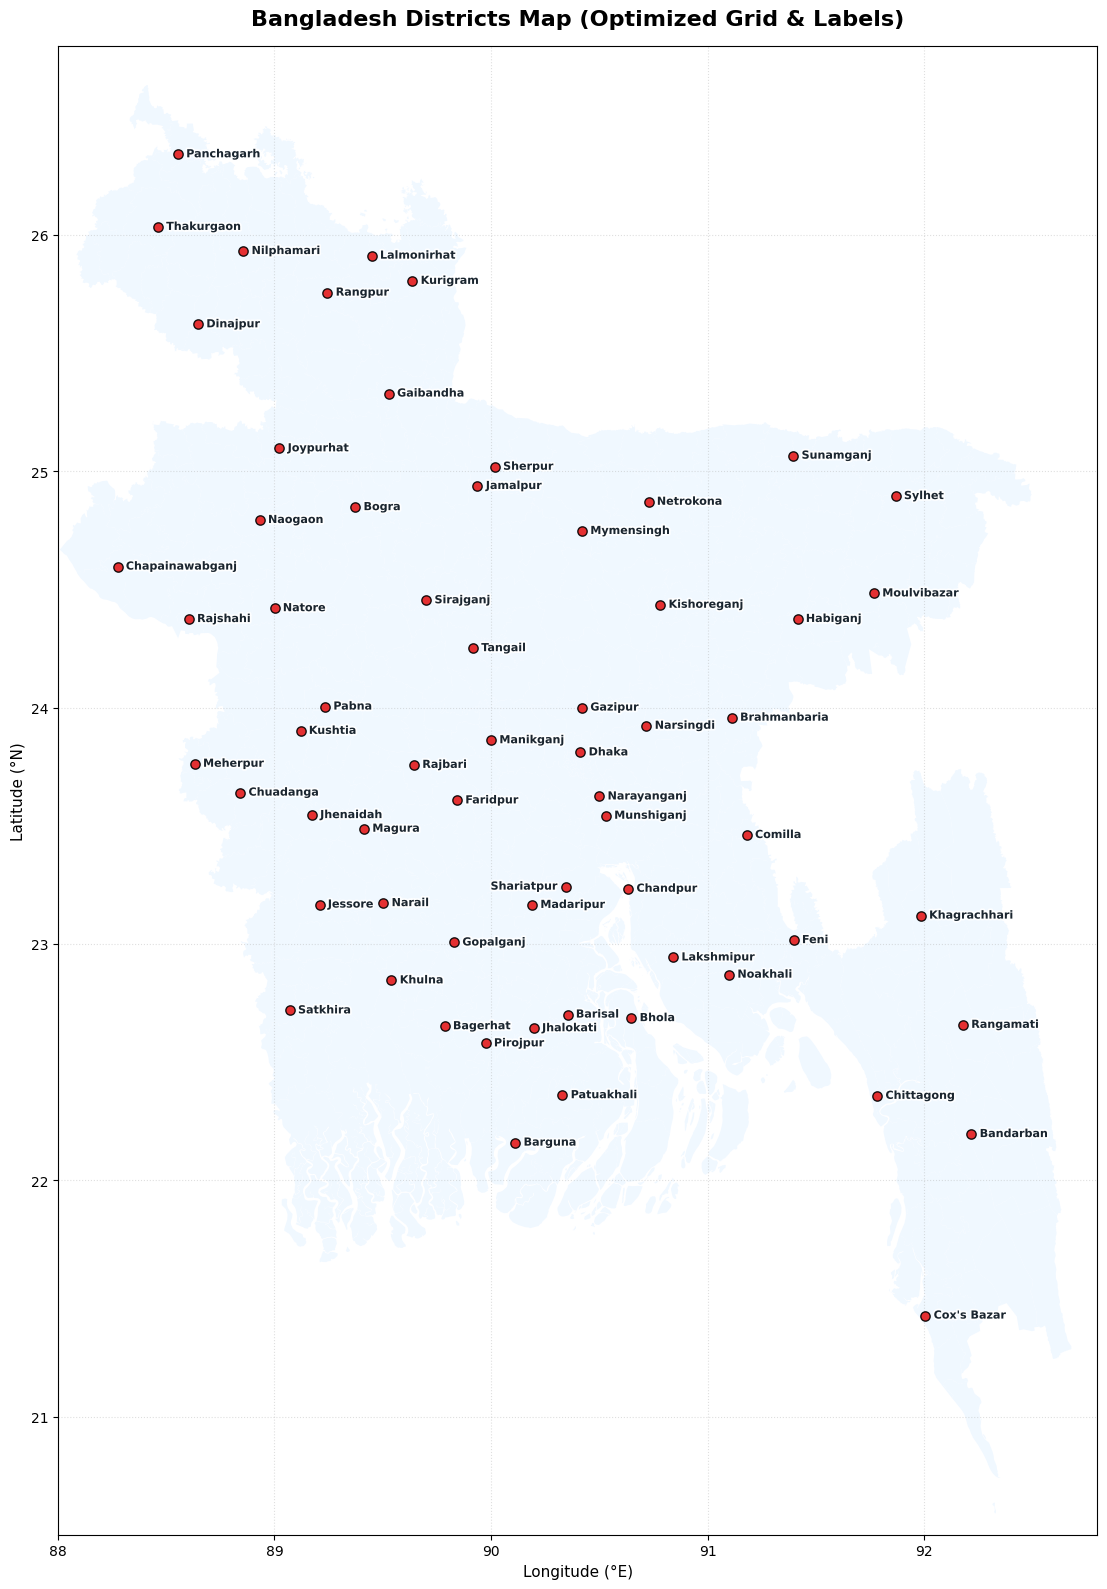

In [19]:
# Map helpers (shared by the overview map and the route map) and the district overview map

GEOJSON_URL = "https://raw.githubusercontent.com/ifahimreza/bangladesh-geojson/master/src/data/bangladesh.geojson"
MAP_XLIM, MAP_YLIM = (88.0, 92.8), (20.5, 26.8)
MARKER_STYLE = dict(color='#e31a1c', edgecolor='black', s=45, zorder=5)
BASE_LABEL_STYLE = dict(fontsize=8, weight='semibold', color='#1a252f')
ROUTE_LABEL_STYLE = dict(fontsize=9, weight='bold', color='black')

# Label positions tried around a marker as (dx, dy, ha, va), in order of visual preference
LABEL_CANDIDATES = [(1, 0, 'left', 'center'), (-1, 0, 'right', 'center'),
                    (1, 1, 'left', 'bottom'), (1, -1, 'left', 'top'),
                    (-1, 1, 'right', 'bottom'), (-1, -1, 'right', 'top'),
                    (0, 1, 'center', 'bottom'), (0, -1, 'center', 'top')]
NOT_PLACED = -1e9    # sentinel box that overlaps nothing


def load_boundary(url=GEOJSON_URL):
    """Load the Bangladesh GeoJSON in EPSG:4326 (lon/lat)."""
    gdf = gpd.read_file(url)
    return gdf.set_crs(epsg=4326) if gdf.crs is None else gdf.to_crs(epsg=4326)


def find_outside_districts(gdf, districts, tolerance=0.03):
    """Districts whose HQ lies outside the boundary (tolerance in degrees: the GeoJSON is simplified)."""
    geometry = gdf.geometry
    country = (geometry.union_all() if hasattr(geometry, "union_all") else geometry.unary_union).buffer(tolerance)
    points = gpd.GeoSeries(gpd.points_from_xy([c['lon'] for c in districts.values()],
                                              [c['lat'] for c in districts.values()]),
                           index=list(districts))
    return points.index[~points.within(country)].tolist()


def overlap_area(boxes, others, pad=0.0):
    """Overlap area between every box in `boxes` (n, 4) and every box in `others` (m, 4); result is (n, m)."""
    w = np.minimum(boxes[:, None, 2], others[None, :, 2] + pad) - np.maximum(boxes[:, None, 0], others[None, :, 0] - pad)
    h = np.minimum(boxes[:, None, 3], others[None, :, 3] + pad) - np.maximum(boxes[:, None, 1], others[None, :, 1] - pad)
    return np.clip(w, 0, None) * np.clip(h, 0, None)


def place_labels(fig, ax, labelled, marker_radius=4.5, gap=6, halo_width=2.5, **text_style):
    """Label the districts in `labelled` next to their markers without overlapping markers or each other.

    Each label is tried at 8 positions around its marker and the position with the fewest overlaps wins.
    Offsets are in points, so a label always sits right beside its own marker. Returns the names of
    labels that still overlap something (normally an empty list).
    """
    fig.tight_layout()
    fig.canvas.draw()
    to_pt = 72.0 / fig.dpi

    names = list(districts)
    row = {name: i for i, name in enumerate(names)}
    xy = ax.transData.transform([(districts[n]['lon'], districts[n]['lat']) for n in names]) * to_pt
    markers = np.hstack([xy - marker_radius, xy + marker_radius])
    extent = ax.get_window_extent()
    bounds = np.array([extent.x0, extent.y0, extent.x1, extent.y1]) * to_pt

    # Candidate boxes (8, 4) for each label, and the placement-independent part of its cost
    candidates, static_cost = {}, {}
    for name in labelled:
        text = ax.text(0, 0, name, **text_style)
        extent_px = text.get_window_extent()
        size = np.array([extent_px.width, extent_px.height]) * to_pt
        text.remove()
        x, y = xy[row[name]]
        corners = np.array([(x + dx * gap - {'right': size[0], 'center': size[0] / 2}.get(ha, 0),
                             y + dy * gap - {'top': size[1], 'center': size[1] / 2}.get(va, 0))
                            for dx, dy, ha, va in LABEL_CANDIDATES])
        boxes = np.hstack([corners, corners + size])
        outside = ((boxes[:, 0] < bounds[0]) | (boxes[:, 2] > bounds[2]) |
                   (boxes[:, 1] < bounds[1]) | (boxes[:, 3] > bounds[3]))
        candidates[name] = boxes
        static_cost[name] = (0.8 * np.arange(len(LABEL_CANDIDATES))
                             + 6 * overlap_area(boxes, markers, 0.5).sum(axis=1)
                             + 500 * outside)

    # Most crowded labels choose first; then a few refinement passes against the other labels
    crowd = {n: int((np.abs(xy - xy[row[n]]) < [60, 25]).all(axis=1).sum()) for n in labelled}
    order = sorted(labelled, key=crowd.get, reverse=True)
    slot = {name: i for i, name in enumerate(labelled)}
    placed = np.full((len(labelled), 4), NOT_PLACED)
    choice = {}
    for _ in range(5):
        for name in order:
            placed[slot[name]] = NOT_PLACED
            cost = static_cost[name] + 2 * overlap_area(candidates[name], placed, 1.0).sum(axis=1)
            choice[name] = int(np.argmin(cost))
            placed[slot[name]] = candidates[name][choice[name]]

    # Draw with a white halo instead of a box, so markers are never hidden
    halo = [pe.withStroke(linewidth=halo_width, foreground='white', alpha=0.9)]
    for name in labelled:
        dx, dy, ha, va = LABEL_CANDIDATES[choice[name]]
        ax.annotate(name, (districts[name]['lon'], districts[name]['lat']), xytext=(dx * gap, dy * gap),
                    textcoords='offset points', ha=ha, va=va, zorder=12, path_effects=halo, **text_style)

    unresolved = []
    for name in labelled:
        i = slot[name]
        on_marker = overlap_area(placed[i:i + 1], markers)[0]
        on_marker[row[name]] = 0
        on_label = overlap_area(placed[i:i + 1], placed)[0]
        on_label[i] = 0
        if on_marker.any() or on_label.any():
            unresolved.append(name)
    return unresolved


def draw_map(title, route=None):
    """Draw the district map. With `route` (list of district names) the route is highlighted and only
    its stops are labelled; without it every district is labelled."""
    fig, ax = plt.subplots(figsize=(14, 16))
    gdf.plot(ax=ax, color="#f0f8ff", edgecolor="none")
    ax.set(xlim=MAP_XLIM, ylim=MAP_YLIM)
    ax.set_xlabel("Longitude (°E)", fontsize=11)
    ax.set_ylabel("Latitude (°N)", fontsize=11)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.grid(True, linestyle=':', alpha=0.4)

    names = list(districts)
    if route is None:
        ax.scatter([districts[n]['lon'] for n in names], [districts[n]['lat'] for n in names],
                   alpha=0.9, **MARKER_STYLE)
        unresolved = place_labels(fig, ax, names, **BASE_LABEL_STYLE)
    else:
        ax.scatter([districts[n]['lon'] for n in names], [districts[n]['lat'] for n in names],
                   alpha=0.3, **MARKER_STYLE)
        lons, lats = [districts[n]['lon'] for n in route], [districts[n]['lat'] for n in route]
        ax.plot(lons, lats, color='#1f78b4', linewidth=5, zorder=10, label='A* Route')
        ax.scatter(lons, lats, color='#ff7f00', edgecolor='black', s=100, zorder=11)
        unresolved = place_labels(fig, ax, route, marker_radius=6, halo_width=3, **ROUTE_LABEL_STYLE)
        ax.legend(loc='upper right')

    if unresolved:
        print("Warning: these labels still overlap something:", unresolved)
    plt.show()


# Load the boundary once, check the marker positions, then draw the overview map
gdf = load_boundary()
outside = find_outside_districts(gdf, districts)
if outside:
    print("Warning: these coordinates fall outside Bangladesh:", outside)
else:
    print(f"Position check passed: all {len(districts)} district markers are inside the boundary.")

draw_map("Bangladesh Districts Map (Optimized Grid & Labels)")

In [20]:
# Core logic: A* search, district-name resolution and input validation


def heuristic_scale(districts, graph):
    """Factor (<= 1) that keeps the straight-line heuristic admissible.

    Straight-line distance only underestimates the road distance if every road is at least as long as
    the line between its endpoints. Scaling by the smallest road/straight-line ratio guarantees
    scale * straight_line(u, v) <= road(u, v) for every edge, so A* always returns the shortest route.
    """
    scale = 1.0
    for u, neighbors in graph.items():
        for v, km in neighbors.items():
            straight = haversine_distance(districts[u], districts[v])
            if straight > 0:
                scale = min(scale, km / straight)
    return scale


# Computed once; pass it to a_star_algorithm so the edges are not re-scanned on every search
HEURISTIC_SCALE = heuristic_scale(districts, graph)


def a_star_algorithm(start, goal, districts, graph, scale=None):
    """Shortest road route from `start` to `goal`. Returns (path, total_km, nodes_explored).

    `scale` is the heuristic scale; when omitted it is computed from the graph (see heuristic_scale).
    """
    if start not in graph or goal not in graph:
        return None, float('inf'), 0

    if scale is None:
        scale = heuristic_scale(districts, graph)
    estimates = {}

    def h(node):
        if node not in estimates:
            estimates[node] = scale * haversine_distance(districts[node], districts[goal])
        return estimates[node]

    best_g = {start: 0}
    parent = {start: None}
    closed = set()
    heap = [(h(start), 0, start)]
    explored = 0

    while heap:
        _, g, current = heapq.heappop(heap)
        if current in closed:
            continue
        closed.add(current)
        explored += 1

        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            return path[::-1], g, explored

        for neighbor, km in graph[current].items():
            new_g = g + km
            if new_g < best_g.get(neighbor, float('inf')):
                best_g[neighbor] = new_g
                parent[neighbor] = current
                heapq.heappush(heap, (new_g + h(neighbor), new_g, neighbor))

    return None, float('inf'), explored


# Resolve user input to a dataset name: ignores case, spaces and apostrophes, and accepts the
# current official spellings (Chattogram, Cumilla, ...) used by the GeoJSON boundary file.
OFFICIAL_SPELLINGS = {"Barishal": "Barisal", "Bogura": "Bogra", "Chattogram": "Chittagong",
                      "Cumilla": "Comilla", "Jashore": "Jessore", "Khagrachari": "Khagrachhari",
                      "Maulvibazar": "Moulvibazar", "Nawabganj": "Chapainawabganj", "Sirajgonj": "Sirajganj"}


def _normalize(text):
    return re.sub(r"[^a-z]", "", text.lower())


NAME_LOOKUP = {_normalize(name): name for name in districts}
NAME_LOOKUP.update({_normalize(alias): name for alias, name in OFFICIAL_SPELLINGS.items()})


def resolve_district(raw):
    """Canonical dataset name for what the user typed, or None."""
    return NAME_LOOKUP.get(_normalize(raw))


def validate_route(raw_source, raw_destination):
    """Return (source, destination, error). `error` is None when the pair is usable."""
    if not raw_source.strip() or not raw_destination.strip():
        return None, None, "Please specify both source and destination districts."
    source, destination = resolve_district(raw_source), resolve_district(raw_destination)
    if source is None:
        return None, None, f"Source '{raw_source}' is not a valid district in this dataset."
    if destination is None:
        return None, None, f"Destination '{raw_destination}' is not a valid district in this dataset."
    if source == destination:
        return None, None, "Source and destination cannot be the same district."
    return source, destination, None


# Selected route, shared by the widget cell and the text-input cell (the last one used wins)
source_district = destination_district = None
is_input_valid = False


def select_route(raw_source, raw_destination):
    """Validate the inputs, remember them for the route cell (is_input_valid) and print a summary."""
    global source_district, destination_district, is_input_valid
    source, destination, error = validate_route(raw_source, raw_destination)
    is_input_valid = error is None
    if error:
        print(f"Error: {error}")
        return

    source_district, destination_district = source, destination
    print(f"Inputs validated: '{source}' -> '{destination}'")
    print(f"  - Source coordinates: {districts[source]}")
    print(f"  - Destination coordinates: {districts[destination]}")
    print(f"  - Direct road link: {graph[source].get(destination, 'none')} km")
    print("Run the route cell to compute the path and render the map overlay.")

In [21]:
# Alternative to the widgets above: type the source and destination district

print("--- District Pathfinder Input ---")
select_route(input("Enter Source District (e.g., Dhaka): "),
             input("Enter Destination District (e.g., Chittagong): "))

--- District Pathfinder Input ---
Enter Source District (e.g., Dhaka): dhaka
Enter Destination District (e.g., Chittagong): bogra
Inputs validated: 'Dhaka' -> 'Bogra'
  - Source coordinates: {'lat': 23.8103, 'lon': 90.4125}
  - Destination coordinates: {'lat': 24.8481, 'lon': 89.373}
  - Direct road link: none km
Run the route cell to compute the path and render the map overlay.


Calculating the optimal path from 'Dhaka' to 'Bogra'...
A* Shortest Path found: Dhaka -> Gazipur -> Tangail -> Sirajganj -> Bogra
Total Route Distance: 220.00 km
Performance Metric: Explored 13 districts/nodes during search.



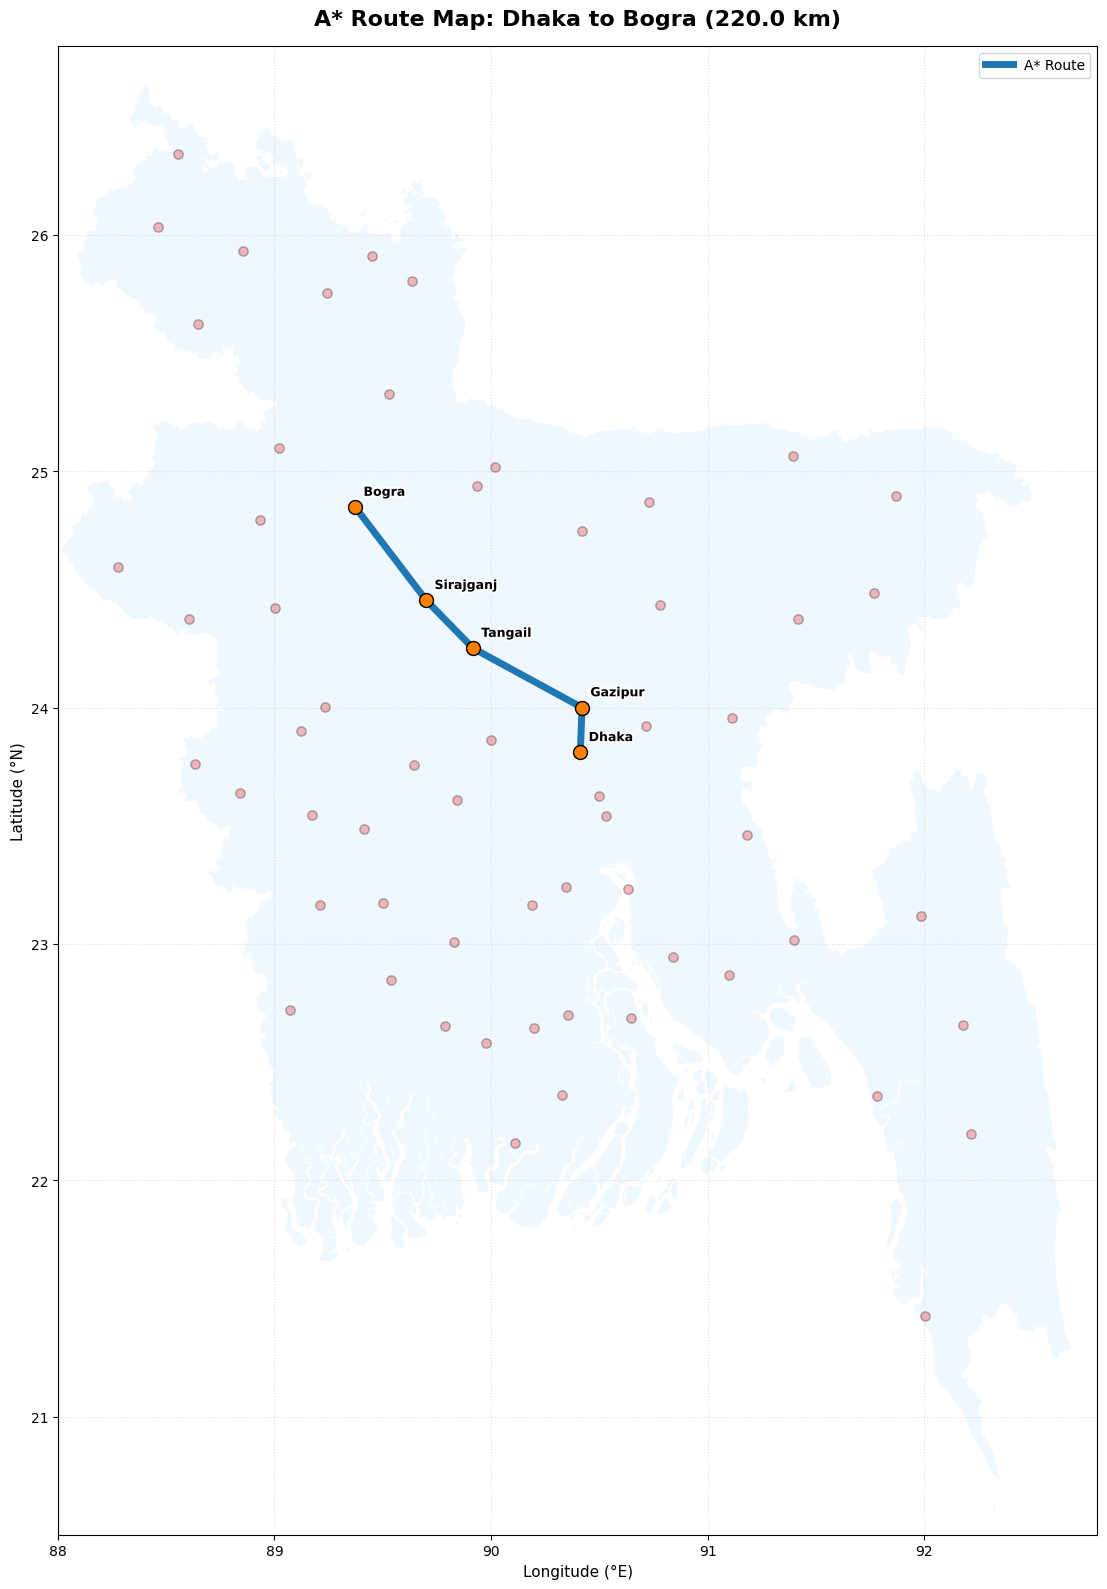

In [22]:
# Calculate the route with A* and render it over the map

if not is_input_valid:
    print("Error: Please validate a source and destination (input cell or widgets) before drawing the route.")
else:
    print(f"Calculating the optimal path from '{source_district}' to '{destination_district}'...")
    path, total_distance, nodes_explored = a_star_algorithm(source_district, destination_district, districts, graph, HEURISTIC_SCALE)

    if path is None:
        print(f"Path not found between {source_district} and {destination_district}.")
        print(f"Total districts explored during search: {nodes_explored}")
    else:
        print(f"A* Shortest Path found: {' -> '.join(path)}")
        print(f"Total Route Distance: {total_distance:.2f} km")
        print(f"Performance Metric: Explored {nodes_explored} districts/nodes during search.\n")
        draw_map(f"A* Route Map: {source_district} to {destination_district} ({total_distance:.1f} km)", route=path)